# Three Players — entrega

Notebook de la entrega: corre los experimentos en el juego matricial simultáneo de 3 jugadores `ThreePlayers` con FP, RM y RandomAgent. Persiste `history` dicts en `data/threeplayers/`, guarda figuras en `images/threeplayers/`, y registra el progreso en `logs/threeplayers/ThreePlayers.log`.

## Configuraciones del juego

Se exploran dos matrices de payoffs distintas, extraídas de la literatura:

- **config=1** — Bonanno, *Game Theory*, fig. 2.22. Juego de 3 jugadores con payoffs ordinales (2 acciones por jugador).
- **config=3** — Aumann, *Randomized strategies*, ejemplo 2.5 (agente 2 tiene 3 acciones, los demás 2).

Para cada configuración se computan los Nash puros analíticamente y se corren los pairings **FP×3**, **RM×3** y **mixto FP+RM+Random** (tres agentes distintos). Cap visual de las gráficas: 500 iteraciones; el history completo (5000 iter) queda en cada `.pkl`.

## Setup

In [ ]:
import sys
sys.path.append('..')

%load_ext autoreload
%autoreload 2

import itertools
import numpy as np
import matplotlib.pyplot as plt

# Juego y agentes del equipo
from games.threeplayers import ThreePlayers
from agents.fictitiousplay import FictitiousPlay
from agents.regretmatching import RegretMatching
from agents.random_agent import RandomAgent

# Infraestructura compartida
from utils.logger import get_logger
from utils.plots import (
    plot_policy_evolution,
    plot_distance_to_nash,
    plot_distance_to_closest_nash,
    plot_cumulative_average_reward,
    plot_cumulative_regret,
    plot_average_positive_regret,
    plot_action_histogram,
)
from utils import experiments as exp

log = get_logger(notebook_name='ThreePlayers')

ITERATIONS = 5000
MAX_ITER = 500

def plot_pair(plot_fn, *args, save: str, **kwargs):
    plot_fn(*args, save=f'threeplayers/{save}', max_iter=MAX_ITER, **kwargs)
    plt.show()

def find_pure_nash(R: np.ndarray, num_actions_per_agent: list[int]):
    out = []
    for joint in itertools.product(*(range(n) for n in num_actions_per_agent)):
        is_ne = True
        for i in range(len(num_actions_per_agent)):
            payoff_i = R[joint][i]
            for alt in range(num_actions_per_agent[i]):
                if alt == joint[i]:
                    continue
                alt_joint = list(joint); alt_joint[i] = alt
                if R[tuple(alt_joint)][i] > payoff_i + 1e-12:
                    is_ne = False; break
            if not is_ne:
                break
        if is_ne:
            out.append((joint, R[joint].tolist()))
    return out

def nash_dict_one_hot(ne_tuple: tuple, num_actions_per_agent: list[int], agents: list[str]):
    """Construye dict[agent → one-hot ndarray] para `plot_distance_to_nash`."""
    out = {}
    for i, a in enumerate(agents):
        v = np.zeros(num_actions_per_agent[i])
        v[ne_tuple[i]] = 1.0
        out[a] = v
    return out

log.info('Setup ThreePlayers listo')

## 4.1 Config 1 — Bonanno fig. 2.22

Juego de 3 jugadores, 2 acciones por jugador. La matriz de payoffs ordinales (extraída de la fig. 2.22 del Bonanno) es:

| (a₀, a₁, a₂) | Payoff (u₀, u₁, u₂) |
|---|---|
| (T, L, W) | (0, 0, 0) |
| (T, L, E) | (0, 0, 0) |
| (T, R, W) | (2, 8, 6) |
| (T, R, E) | (1, 2, 5) |
| (B, L, W) | (5, 3, 2) |
| (B, L, E) | (1, 6, 1) |
| (B, R, W) | (3, 4, 2) |
| (B, R, E) | (0, 0, 1) |

donde agente 0 elige entre T (Top) y B (Bottom), agente 1 entre L (Left) y R (Right), agente 2 entre W (West) y E (East).

### Equilibrios puros analíticos — config 1

Verificación sistemática enumerando todos los joint outcomes y comprobando si cada agente está jugando una mejor respuesta dados los otros dos.

In [ ]:
g1 = ThreePlayers(config=1)
g1.reset()
info1 = g1.get_config_info()
labels1 = info1['action_labels']
num_actions1 = info1['num_actions_per_agent']
agents1 = list(g1.agents)

ne_list1 = find_pure_nash(g1._R, num_actions1)
log.info('Config 1 — Nash puros encontrados: ' + str([
    (tuple(labels1[agents1[i]][ne[i]] for i in range(3)), payoff)
    for ne, payoff in ne_list1
]))
for ne, payoff in ne_list1:
    pretty = tuple(labels1[agents1[i]][ne[i]] for i in range(3))
    print(f'NE {pretty} (índice {ne}) → payoff {payoff}')

2026-05-27 13:05:34 | INFO    | Config 1 — Nash puros encontrados: [(('B', 'R', 'W'), [3.0, 4.0, 2.0])]


NE ('B', 'R', 'W') (índice (1, 1, 0)) → payoff [3.0, 4.0, 2.0]


In [ ]:
unique_ne1 = ne_list1[0] if len(ne_list1) == 1 else None
if unique_ne1 is not None:
    nash_dict1 = nash_dict_one_hot(unique_ne1[0], num_actions1, agents1)
    log.info('Config 1: usando Nash one-hot único para distance_to_nash')
else:
    nash_dict1 = None
    log.info(f'Config 1: {len(ne_list1)} NE puros — distance se mide al más cercano')

2026-05-27 13:05:34 | INFO    | Config 1: usando Nash one-hot único para distance_to_nash


### FP × 3 — config 1

Tres agentes Fictitious Play. Se espera convergencia a alguno de los Nash puros (si hay) o un patrón cíclico si la dinámica no se estabiliza.

In [ ]:
log.info('ThreePlayers c1 — FP×3 — iniciando experimento')
init_c1 = {a: np.ones(n, dtype=int) for a, n in zip(agents1, num_actions1)}
pair_fp_c1 = [(FictitiousPlay, {'initial': init_c1})] * 3
hist_c1_fp = exp.cached_run('threeplayers_c1_fp_x3', ThreePlayers(config=1), pair_fp_c1, iterations=ITERATIONS, seed=1)

for a in agents1:
    pol = hist_c1_fp['policy_history'][a][-1]
    am = int(np.argmax(pol)); lab = labels1[a][am]
    log.info(f'c1 FP×3 — {a}: política final = {pol.round(3)} (argmax = {lab})')

2026-05-27 13:05:34 | INFO    | ThreePlayers c1 — FP×3 — iniciando experimento


2026-05-27 13:05:35 | INFO    | c1 FP×3 — agent_0: política final = [0. 1.] (argmax = B)


2026-05-27 13:05:35 | INFO    | c1 FP×3 — agent_1: política final = [0. 1.] (argmax = R)


2026-05-27 13:05:35 | INFO    | c1 FP×3 — agent_2: política final = [1. 0.] (argmax = W)


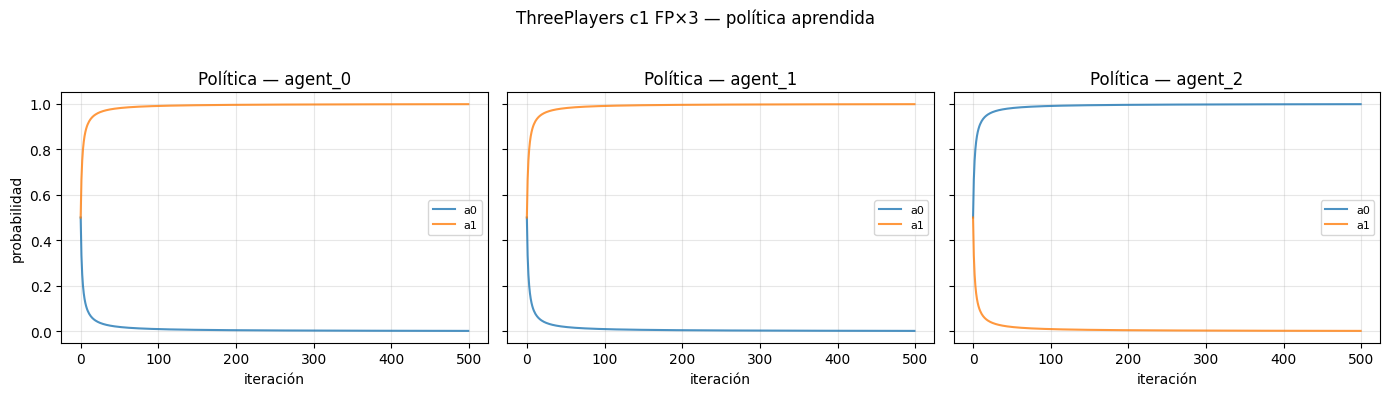

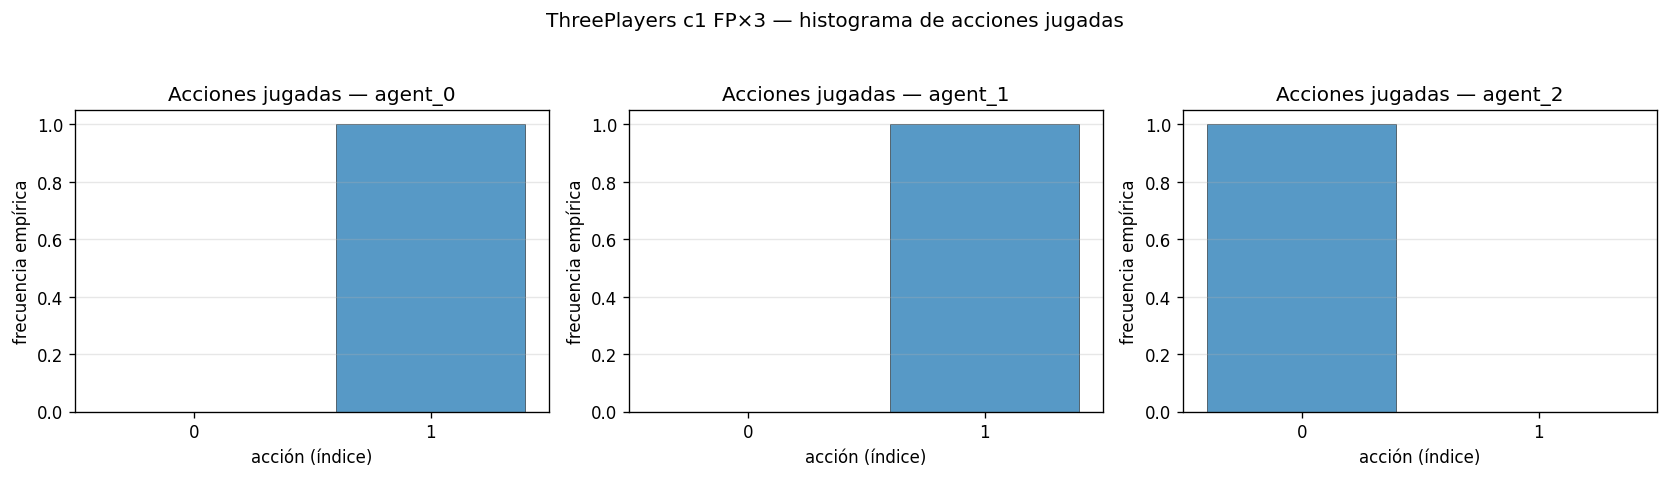

In [ ]:
plot_pair(plot_policy_evolution, hist_c1_fp, action_labels=None, figsize=(14, 4), save='c1_fp_x3_policy', title='ThreePlayers c1 FP×3 — política aprendida')

plot_pair(plot_action_histogram, hist_c1_fp, figsize=(14, 4), save='c1_fp_x3_actions_hist', title='ThreePlayers c1 FP×3 — histograma de acciones jugadas')

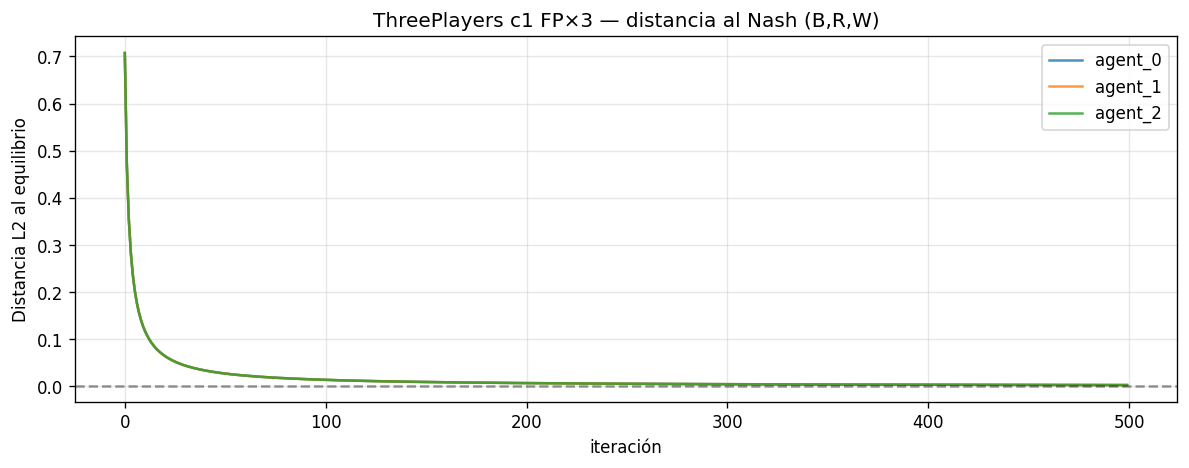

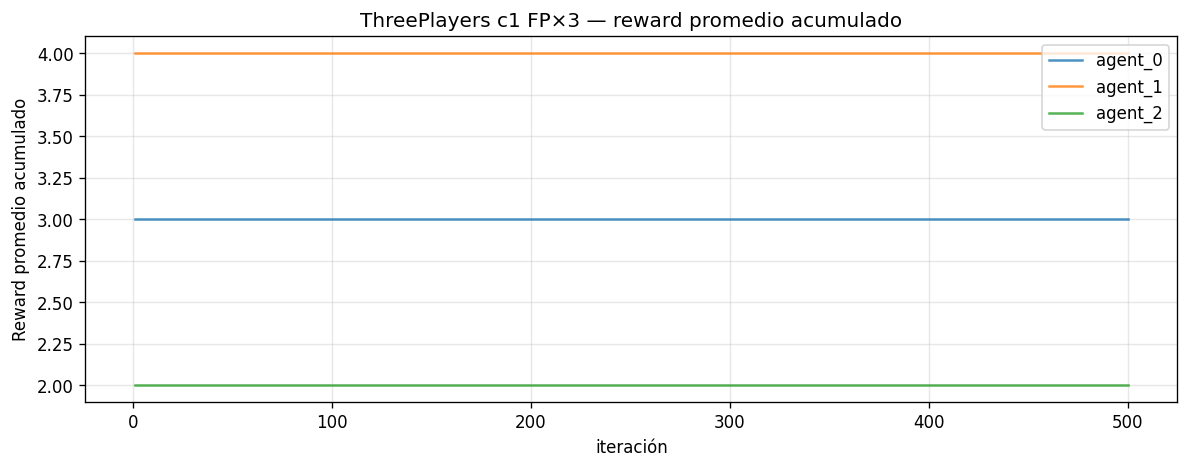

In [ ]:
plot_pair(plot_distance_to_nash, hist_c1_fp, nash_dict1, save='c1_fp_x3_distance_to_nash', title='ThreePlayers c1 FP×3 — distancia al Nash (B,R,W)')

plot_pair(plot_cumulative_average_reward, hist_c1_fp, save='c1_fp_x3_reward_cum_avg', title='ThreePlayers c1 FP×3 — reward promedio acumulado')

### RM × 3 — config 1

Tres agentes Regret Matching. Se espera convergencia (en política promedio) a alguno de los Nash puros. c1 tiene un único Nash puro $(B, R, W)$, así que se espera que la política promedio de los tres agentes converja ahí.

In [ ]:
log.info('ThreePlayers c1 — RM×3 — iniciando experimento')
pair_rm_c1 = [(RegretMatching, {})] * 3
hist_c1_rm = exp.cached_run('threeplayers_c1_rm_x3', ThreePlayers(config=1), pair_rm_c1, iterations=ITERATIONS, seed=1)

for a in agents1:
    pol = hist_c1_rm['policy_history'][a][-1]
    am = int(np.argmax(pol)); lab = labels1[a][am]
    log.info(f'c1 RM×3 — {a}: política promedio = {pol.round(3)} (argmax = {lab})')

2026-05-27 13:05:35 | INFO    | ThreePlayers c1 — RM×3 — iniciando experimento


2026-05-27 13:05:37 | INFO    | c1 RM×3 — agent_0: política promedio = [0.001 0.999] (argmax = B)


2026-05-27 13:05:37 | INFO    | c1 RM×3 — agent_1: política promedio = [0. 1.] (argmax = R)


2026-05-27 13:05:37 | INFO    | c1 RM×3 — agent_2: política promedio = [1. 0.] (argmax = W)


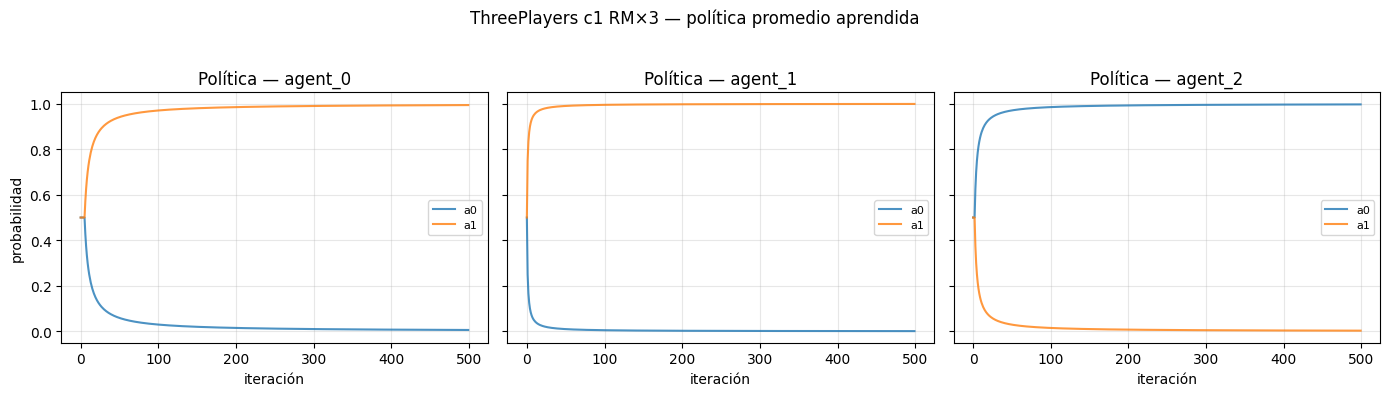

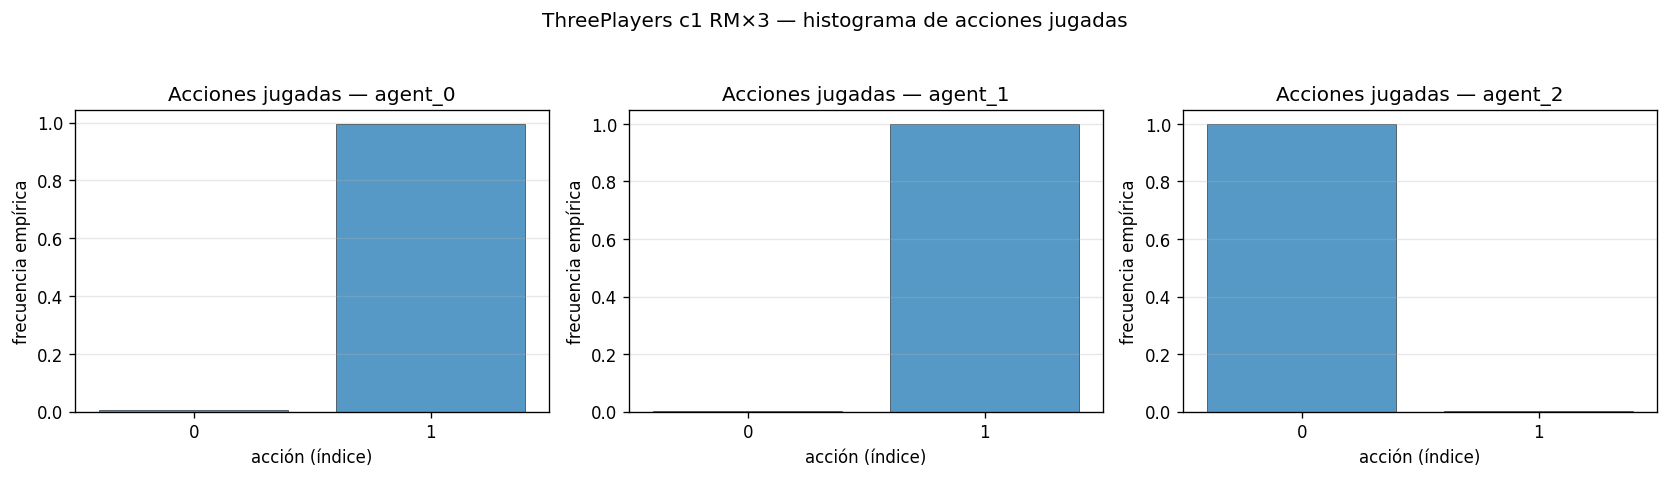

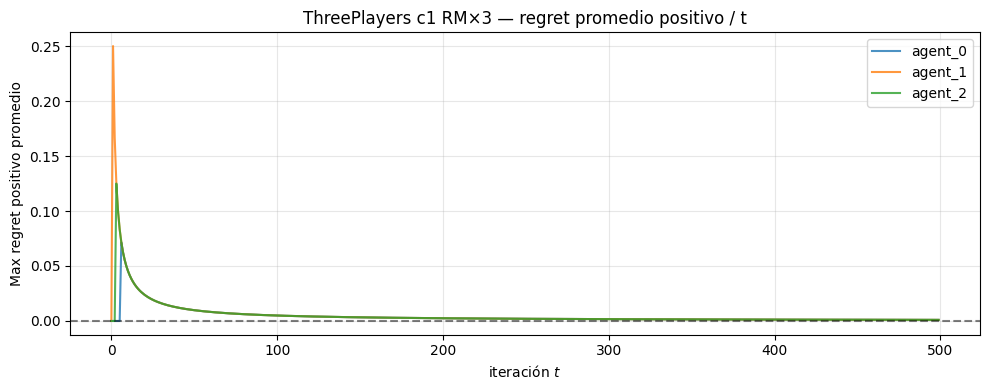

In [ ]:
plot_pair(plot_policy_evolution, hist_c1_rm, action_labels=None, figsize=(14, 4), save='c1_rm_x3_policy', title='ThreePlayers c1 RM×3 — política promedio aprendida')

plot_pair(plot_action_histogram, hist_c1_rm, figsize=(14, 4), save='c1_rm_x3_actions_hist', title='ThreePlayers c1 RM×3 — histograma de acciones jugadas')

plot_pair(plot_average_positive_regret, hist_c1_rm, save='c1_rm_x3_avg_pos_regret', title='ThreePlayers c1 RM×3 — regret promedio positivo / t')

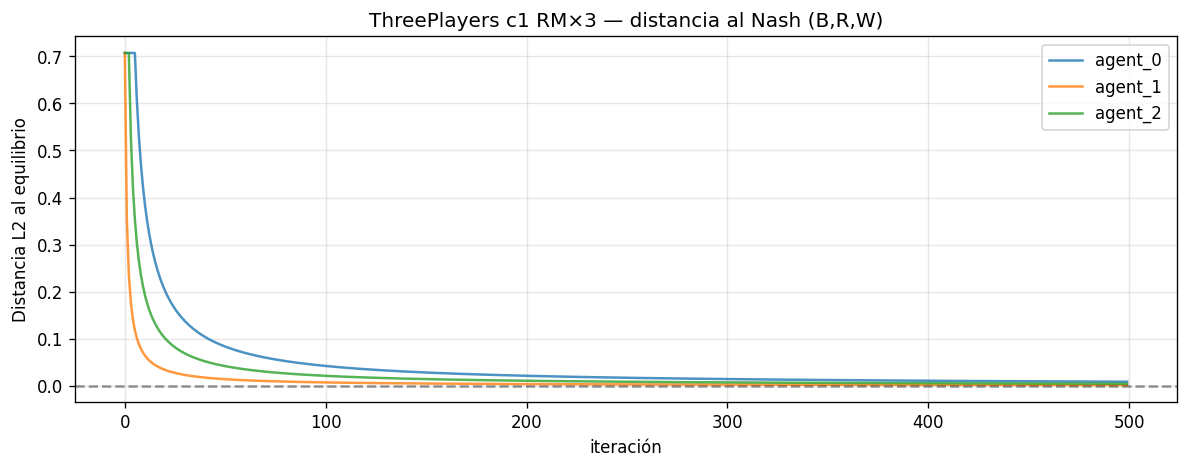

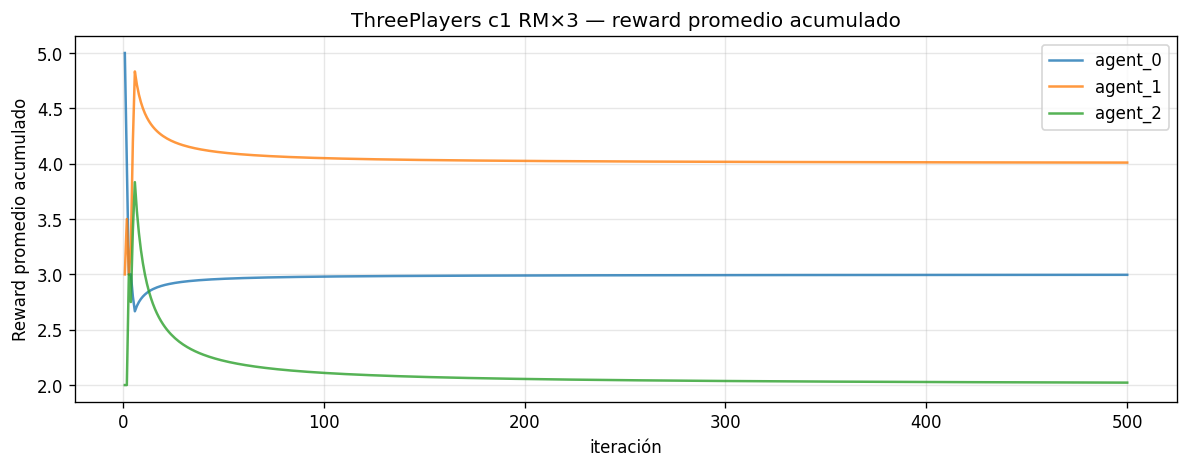

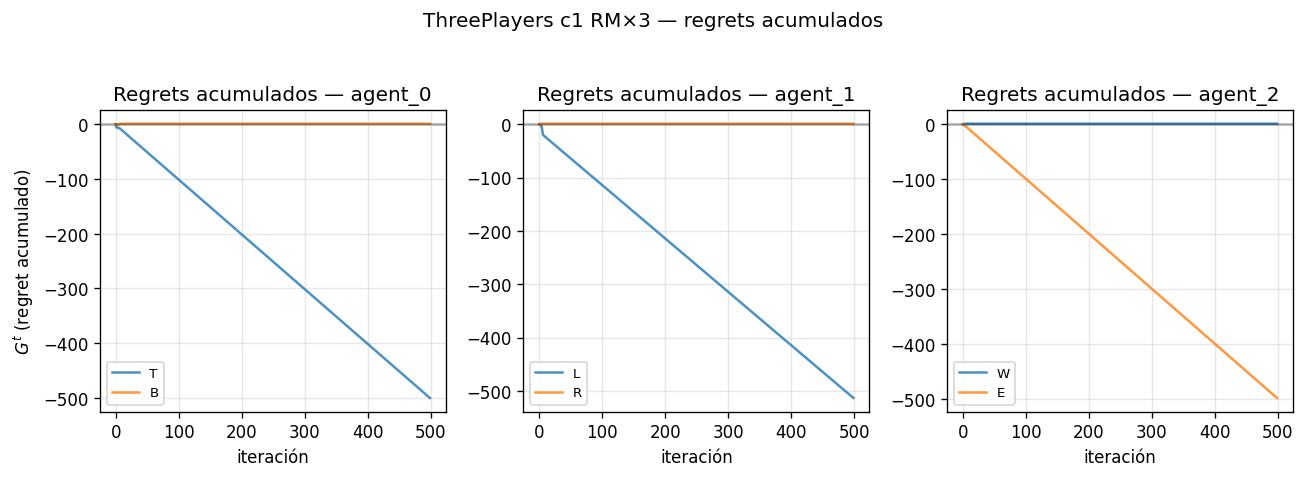

In [ ]:
# Gráficas adicionales — alineadas con MP/RPS
plot_pair(plot_distance_to_nash, hist_c1_rm, nash_dict1, save='c1_rm_x3_distance_to_nash', title='ThreePlayers c1 RM×3 — distancia al Nash (B,R,W)')

plot_pair(plot_cumulative_average_reward, hist_c1_rm, save='c1_rm_x3_reward_cum_avg', title='ThreePlayers c1 RM×3 — reward promedio acumulado')

plot_pair(plot_cumulative_regret, hist_c1_rm, save='c1_rm_x3_cum_regrets', title='ThreePlayers c1 RM×3 — regrets acumulados')

### Mixto FP + RM + Random — config 1

Tres agentes de tipo distinto: uno greedy (FP), uno regret-matching (RM) y uno no estratégico (Random). Permite ver cómo se comporta cada algoritmo cuando enfrenta simultáneamente a un rival que aprende y a un rival no estratégico. En c1, agent_2 (Random) sortea uniforme entre 2 acciones (W/E).

In [ ]:
log.info('ThreePlayers c1 — FP + RM + Random — iniciando experimento')
pair_mix_c1 = [(FictitiousPlay, {'initial': init_c1}), (RegretMatching, {}), (RandomAgent, {})]
hist_c1_mix = exp.cached_run('threeplayers_c1_fp_rm_random', ThreePlayers(config=1), pair_mix_c1, iterations=ITERATIONS, seed=1)

for a in agents1:
    pol = hist_c1_mix['policy_history'][a][-1]
    am = int(np.argmax(pol)); lab = labels1[a][am]
    log.info(f'c1 FP+RM+Random — {a}: política final = {pol.round(3)} (argmax = {lab})')

2026-05-27 13:05:37 | INFO    | ThreePlayers c1 — FP + RM + Random — iniciando experimento


2026-05-27 13:05:38 | INFO    | c1 FP+RM+Random — agent_0: política final = [0. 1.] (argmax = B)


2026-05-27 13:05:38 | INFO    | c1 FP+RM+Random — agent_1: política final = [1. 0.] (argmax = L)


2026-05-27 13:05:38 | INFO    | c1 FP+RM+Random — agent_2: política final = [0.5 0.5] (argmax = W)


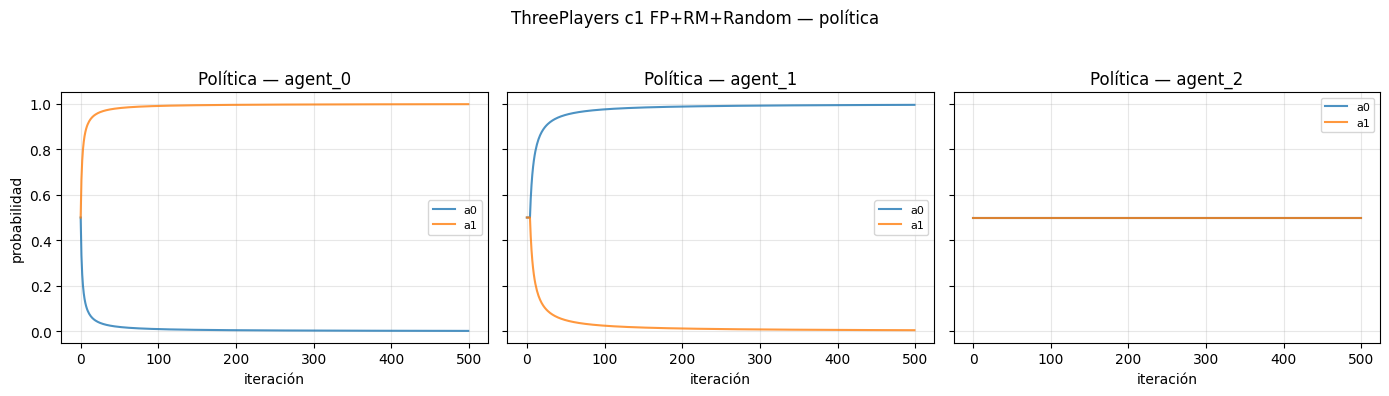

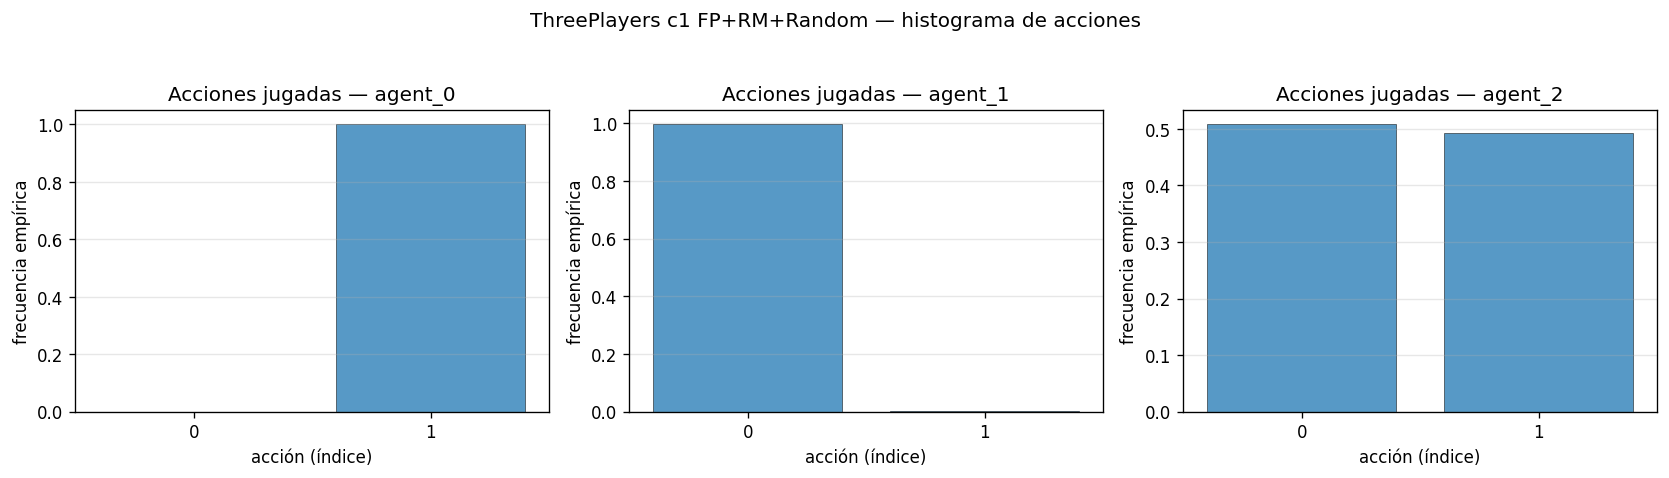

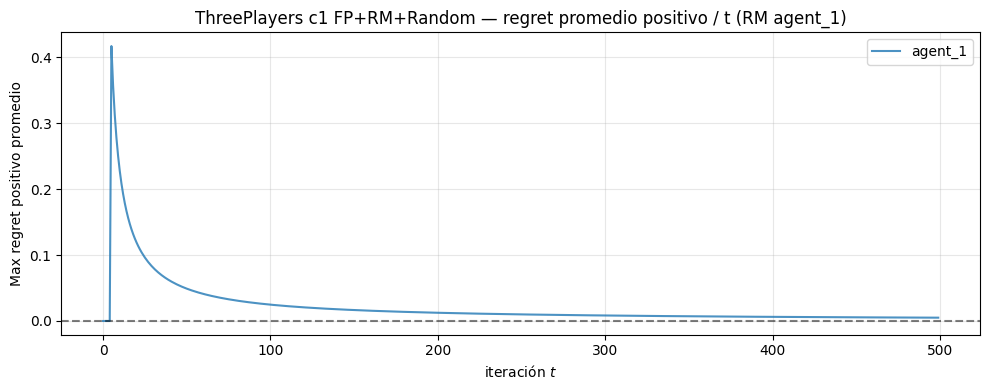

In [ ]:
plot_pair(plot_policy_evolution, hist_c1_mix, action_labels=None, figsize=(14, 4), save='c1_fp_rm_random_policy', title='ThreePlayers c1 FP+RM+Random — política')

plot_pair(plot_action_histogram, hist_c1_mix, figsize=(14, 4), save='c1_fp_rm_random_actions_hist', title='ThreePlayers c1 FP+RM+Random — histograma de acciones')

plot_pair(plot_average_positive_regret, hist_c1_mix, save='c1_fp_rm_random_avg_pos_regret', title='ThreePlayers c1 FP+RM+Random — regret promedio positivo / t (RM agent_1)')

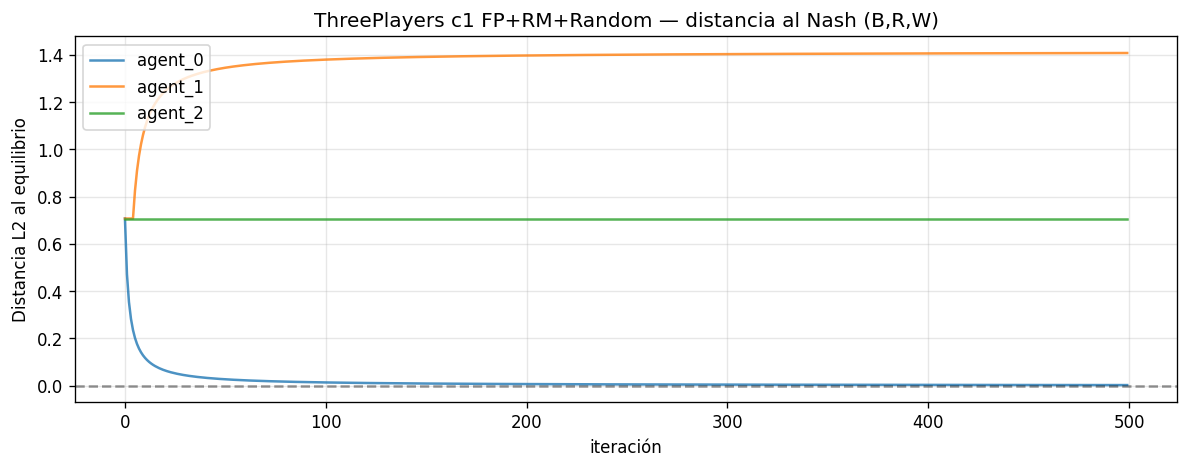

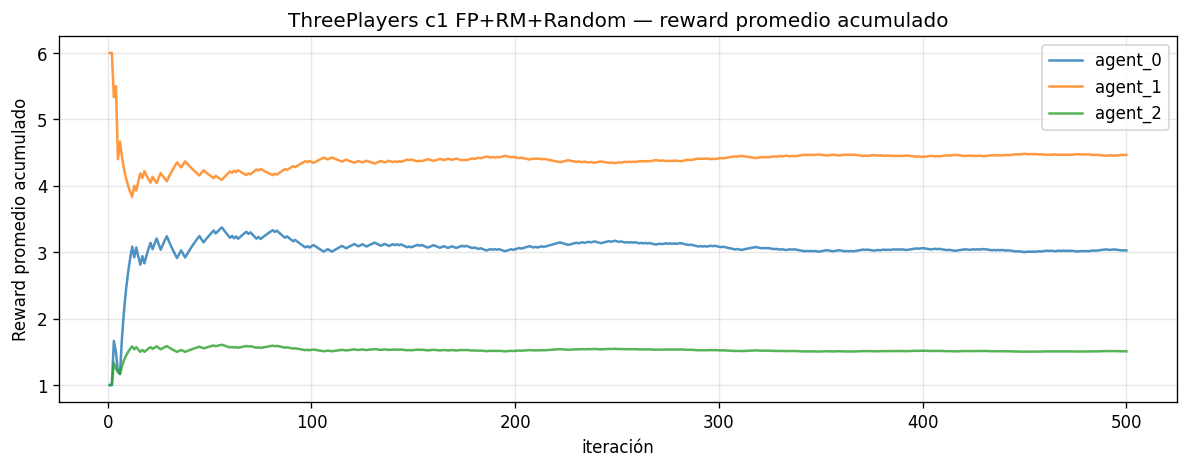

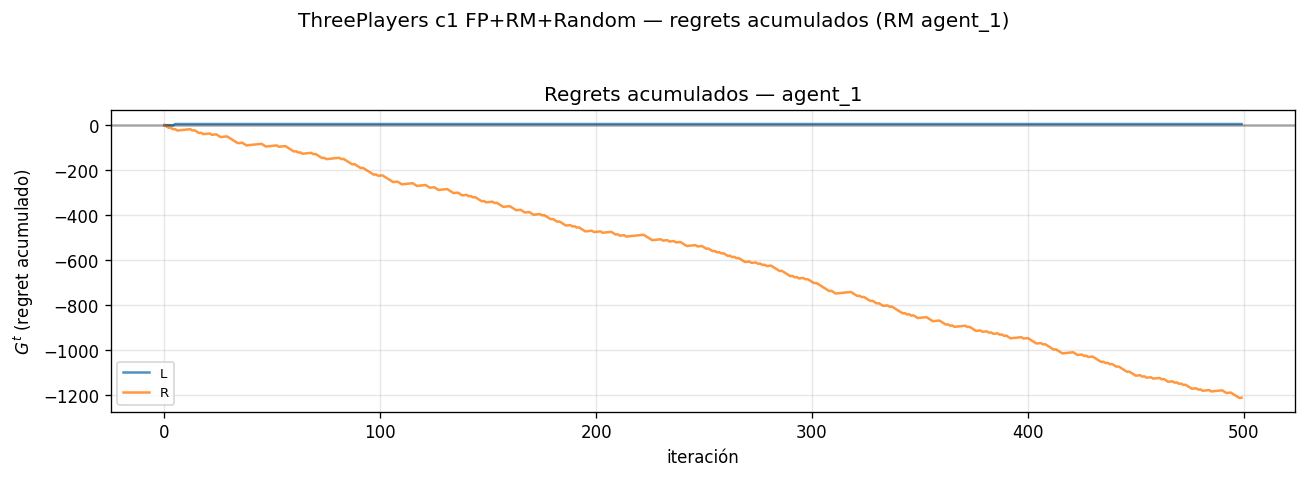

In [ ]:
# Gráficas adicionales — alineadas con MP/RPS
plot_pair(plot_distance_to_nash, hist_c1_mix, nash_dict1, save='c1_fp_rm_random_distance_to_nash', title='ThreePlayers c1 FP+RM+Random — distancia al Nash (B,R,W)')

plot_pair(plot_cumulative_average_reward, hist_c1_mix, save='c1_fp_rm_random_reward_cum_avg', title='ThreePlayers c1 FP+RM+Random — reward promedio acumulado')

plot_pair(plot_cumulative_regret, hist_c1_mix, save='c1_fp_rm_random_cum_regrets', title='ThreePlayers c1 FP+RM+Random — regrets acumulados (RM agent_1)')

## 4.2 Config 3 — Aumann, ejemplo 2.5

Tres jugadores; el agente 2 tiene 3 acciones (W, E, N) mientras que los agentes 0 y 1 tienen 2 cada uno (T/B y L/R). La matriz de payoffs (shape 2×2×3×3) es:

| (a₀, a₁, a₂) | Payoff (u₀, u₁, u₂) |
|---|---|
| (T, L, W) | (0, 0, 3) |
| (T, L, E) | (2, 2, 2) |
| (T, L, N) | (0, 0, 0) |
| (T, R, W) | (0, 0, 0) |
| (T, R, E) | (0, 0, 0) |
| (T, R, N) | (0, 0, 0) |
| (B, L, W) | (1, 0, 0) |
| (B, L, E) | (0, 0, 0) |
| (B, L, N) | (0, 1, 0) |
| (B, R, W) | (0, 0, 0) |
| (B, R, E) | (2, 2, 2) |
| (B, R, N) | (0, 0, 3) |

### Equilibrios puros analíticos — config 3

Verificación sistemática enumerando todos los joint outcomes y comprobando si cada agente está jugando una mejor respuesta dados los otros dos.

In [ ]:
g3 = ThreePlayers(config=3)
g3.reset()
info3 = g3.get_config_info()
labels3 = info3['action_labels']
num_actions3 = info3['num_actions_per_agent']
agents3 = list(g3.agents)

ne_list3 = find_pure_nash(g3._R, num_actions3)
log.info('Config 3 — Nash puros encontrados: ' + str([
    (tuple(labels3[agents3[i]][ne[i]] for i in range(3)), payoff)
    for ne, payoff in ne_list3
]))
for ne, payoff in ne_list3:
    pretty = tuple(labels3[agents3[i]][ne[i]] for i in range(3))
    print(f'NE {pretty} (índice {ne}) → payoff {payoff}')

2026-05-27 13:05:39 | INFO    | Config 3 — Nash puros encontrados: [(('T', 'R', 'W'), [0.0, 0.0, 0.0]), (('T', 'R', 'N'), [0.0, 0.0, 0.0]), (('B', 'L', 'W'), [1.0, 0.0, 0.0]), (('B', 'L', 'N'), [0.0, 1.0, 0.0])]


NE ('T', 'R', 'W') (índice (0, 1, 0)) → payoff [0.0, 0.0, 0.0]
NE ('T', 'R', 'N') (índice (0, 1, 2)) → payoff [0.0, 0.0, 0.0]
NE ('B', 'L', 'W') (índice (1, 0, 0)) → payoff [1.0, 0.0, 0.0]
NE ('B', 'L', 'N') (índice (1, 0, 2)) → payoff [0.0, 1.0, 0.0]


### FP × 3 — config 3

Tres agentes Fictitious Play. Esta configuración corresponde al **ejemplo 2.5 de Aumann**, que muestra que FP no converge a ningún Nash puro: las mejores respuestas de cada agente a la frecuencia empírica de los rivales rotan entre los 4 Nash puros del juego.

In [ ]:
log.info('ThreePlayers c3 — FP×3 — iniciando experimento')
init_c3 = {a: np.ones(n, dtype=int) for a, n in zip(agents3, num_actions3)}
pair_fp_c3 = [(FictitiousPlay, {'initial': init_c3})] * 3
hist_c3_fp = exp.cached_run('threeplayers_c3_fp_x3', ThreePlayers(config=3), pair_fp_c3, iterations=ITERATIONS, seed=1)

for a in agents3:
    pol = hist_c3_fp['policy_history'][a][-1]
    if np.allclose(pol, 1.0 / len(pol), atol=1e-3):
        log.info(f'c3 FP×3 — {a}: política final = {pol.round(3)} (uniforme — argmax arbitrario)')
    else:
        am = int(np.argmax(pol)); lab = labels3[a][am]
        log.info(f'c3 FP×3 — {a}: política final = {pol.round(3)} (argmax = {lab})')

2026-05-27 13:05:39 | INFO    | ThreePlayers c3 — FP×3 — iniciando experimento


2026-05-27 13:05:39 | INFO    | c3 FP×3 — agent_0: política final = [0.5 0.5] (uniforme — argmax arbitrario)


2026-05-27 13:05:39 | INFO    | c3 FP×3 — agent_1: política final = [0.5 0.5] (uniforme — argmax arbitrario)


2026-05-27 13:05:39 | INFO    | c3 FP×3 — agent_2: política final = [0. 1. 0.] (argmax = E)


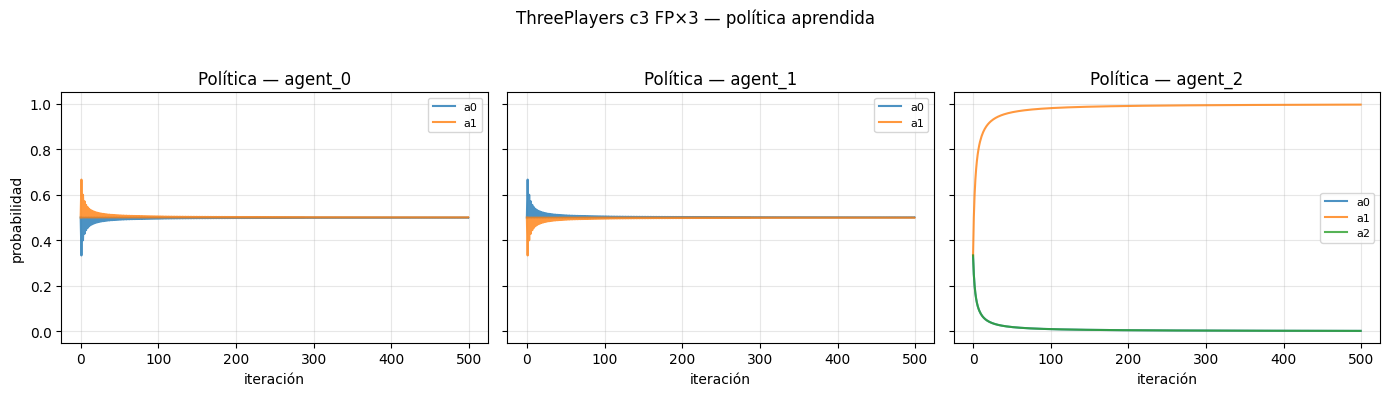

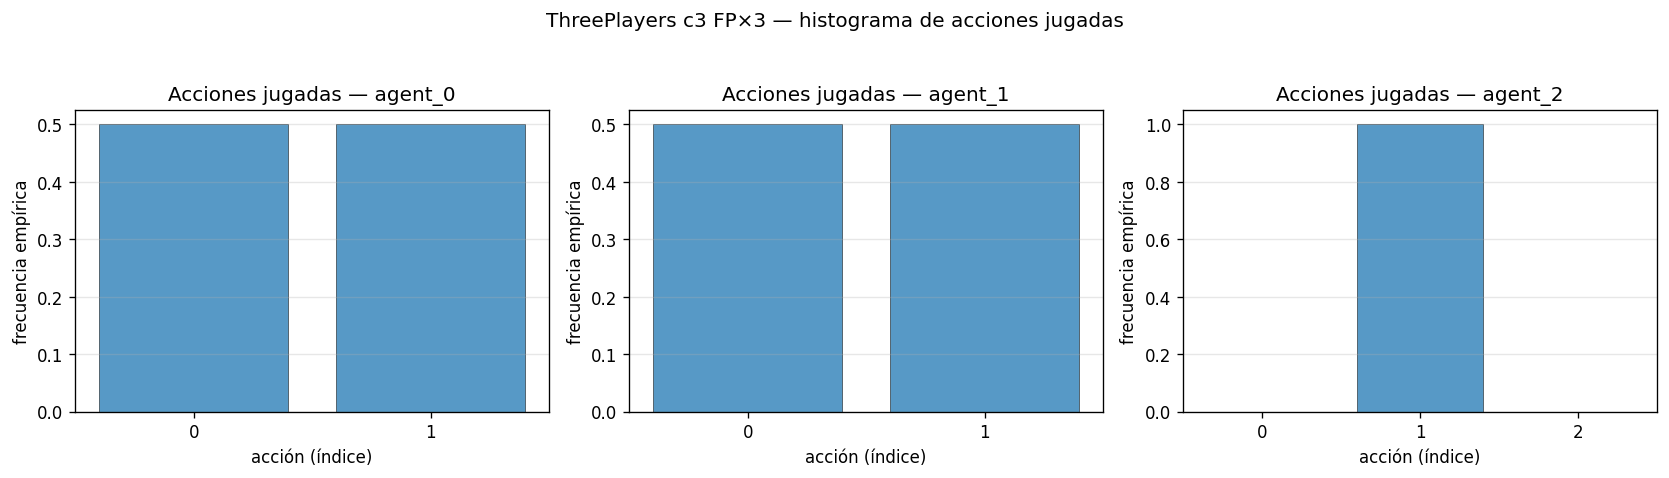

In [ ]:
plot_pair(plot_policy_evolution, hist_c3_fp, action_labels=None, figsize=(14, 4), save='c3_fp_x3_policy', title='ThreePlayers c3 FP×3 — política aprendida')

plot_pair(plot_action_histogram, hist_c3_fp, figsize=(14, 4), save='c3_fp_x3_actions_hist', title='ThreePlayers c3 FP×3 — histograma de acciones jugadas')

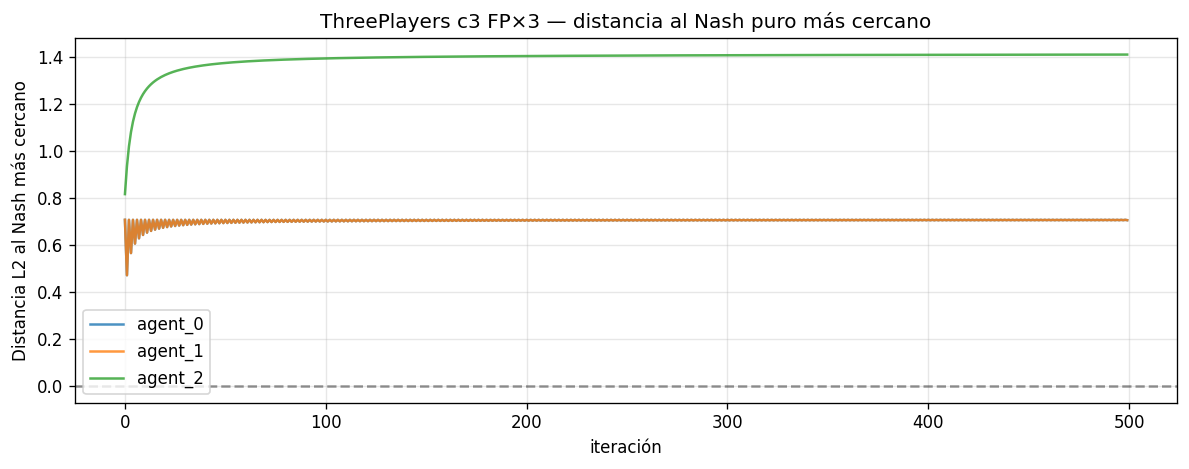

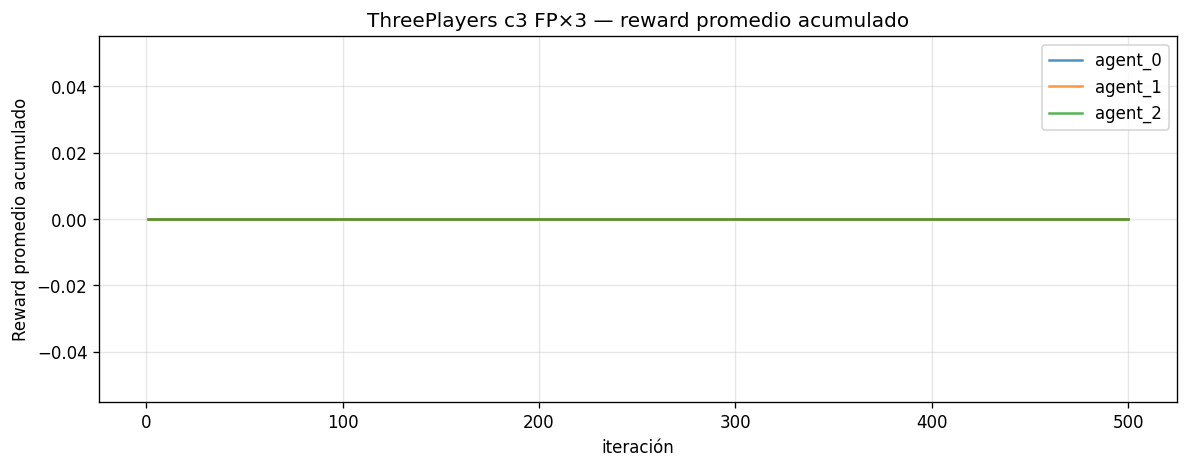

In [ ]:
nash_dicts3 = []
for ne, _ in ne_list3:
    hots = {}
    for i, a in enumerate(agents3):
        v = np.zeros(num_actions3[i]); v[ne[i]] = 1.0; hots[a] = v
    nash_dicts3.append(hots)

plot_pair(plot_distance_to_closest_nash, hist_c3_fp, nash_dicts3, save='c3_fp_x3_distance_to_nash', title='ThreePlayers c3 FP×3 — distancia al Nash puro más cercano')

plot_pair(plot_cumulative_average_reward, hist_c3_fp, save='c3_fp_x3_reward_cum_avg', title='ThreePlayers c3 FP×3 — reward promedio acumulado')

### RM × 3 — config 3

Tres agentes Regret Matching. Se espera convergencia (en política promedio) a alguno de los Nash puros. c3 tiene 4 Nash puros, así que la política promedio puede asentarse en cualquiera de ellos; la garantía no-regret se cumple independientemente de cuál sea el límite.

In [ ]:
log.info('ThreePlayers c3 — RM×3 — iniciando experimento')
pair_rm_c3 = [(RegretMatching, {})] * 3
hist_c3_rm = exp.cached_run('threeplayers_c3_rm_x3', ThreePlayers(config=3), pair_rm_c3, iterations=ITERATIONS, seed=1)

for a in agents3:
    pol = hist_c3_rm['policy_history'][a][-1]
    am = int(np.argmax(pol)); lab = labels3[a][am]
    log.info(f'c3 RM×3 — {a}: política promedio = {pol.round(3)} (argmax = {lab})')

2026-05-27 13:05:40 | INFO    | ThreePlayers c3 — RM×3 — iniciando experimento


2026-05-27 13:05:41 | INFO    | c3 RM×3 — agent_0: política promedio = [0.001 0.999] (argmax = B)


2026-05-27 13:05:41 | INFO    | c3 RM×3 — agent_1: política promedio = [0.996 0.004] (argmax = L)


2026-05-27 13:05:41 | INFO    | c3 RM×3 — agent_2: política promedio = [0.001 0.001 0.998] (argmax = N)


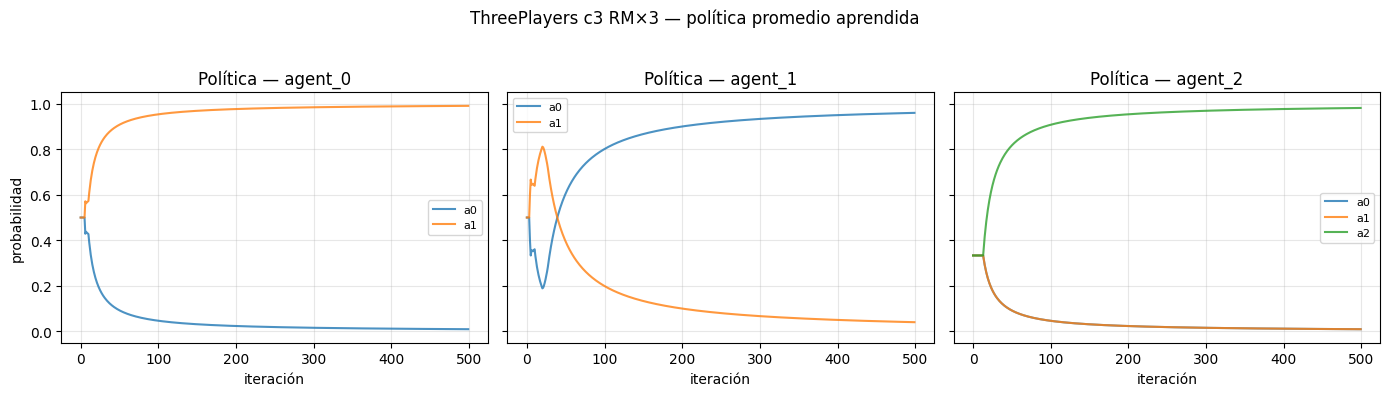

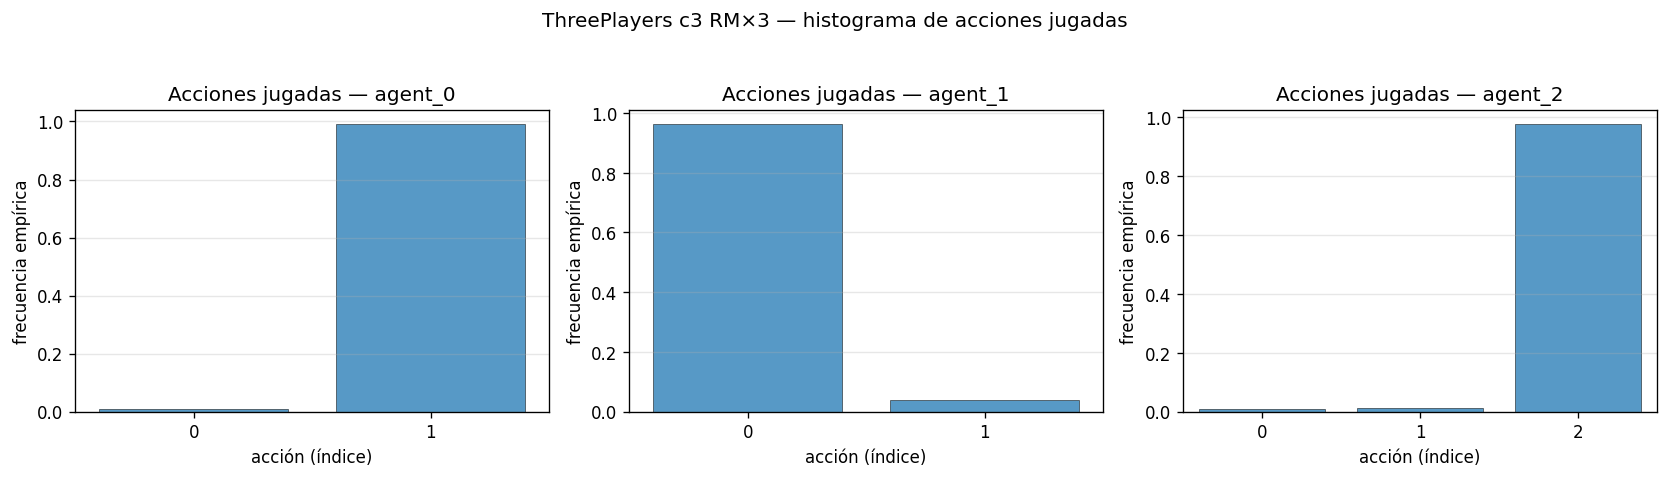

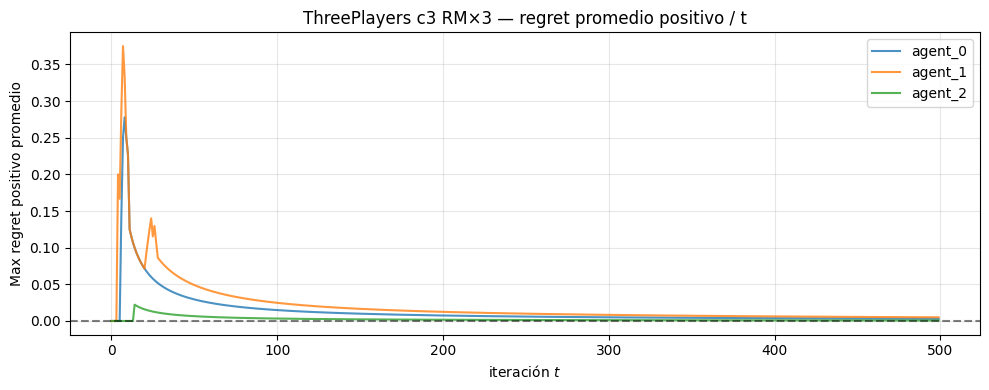

In [ ]:
plot_pair(plot_policy_evolution, hist_c3_rm, action_labels=None, figsize=(14, 4), save='c3_rm_x3_policy', title='ThreePlayers c3 RM×3 — política promedio aprendida')

plot_pair(plot_action_histogram, hist_c3_rm, figsize=(14, 4), save='c3_rm_x3_actions_hist', title='ThreePlayers c3 RM×3 — histograma de acciones jugadas')

plot_pair(plot_average_positive_regret, hist_c3_rm, save='c3_rm_x3_avg_pos_regret', title='ThreePlayers c3 RM×3 — regret promedio positivo / t')

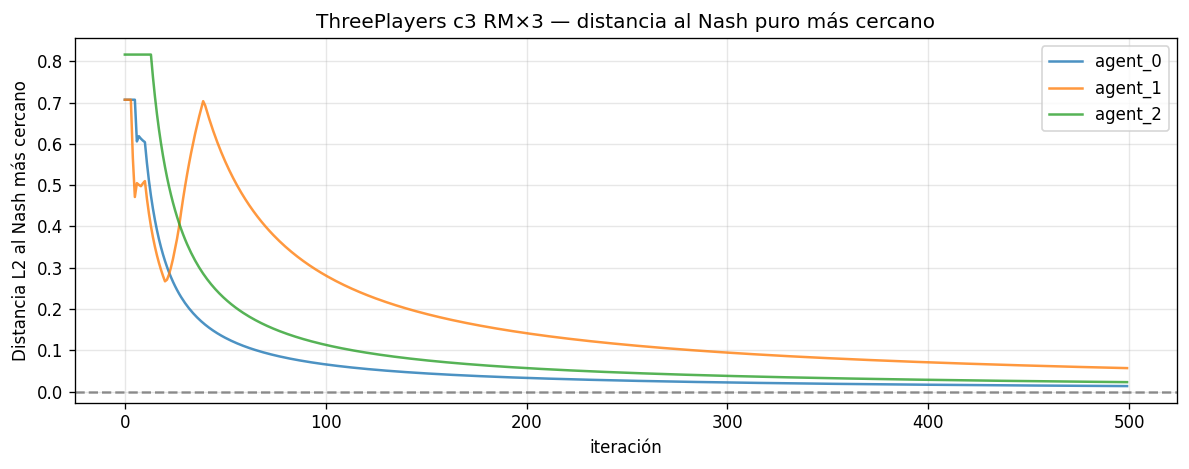

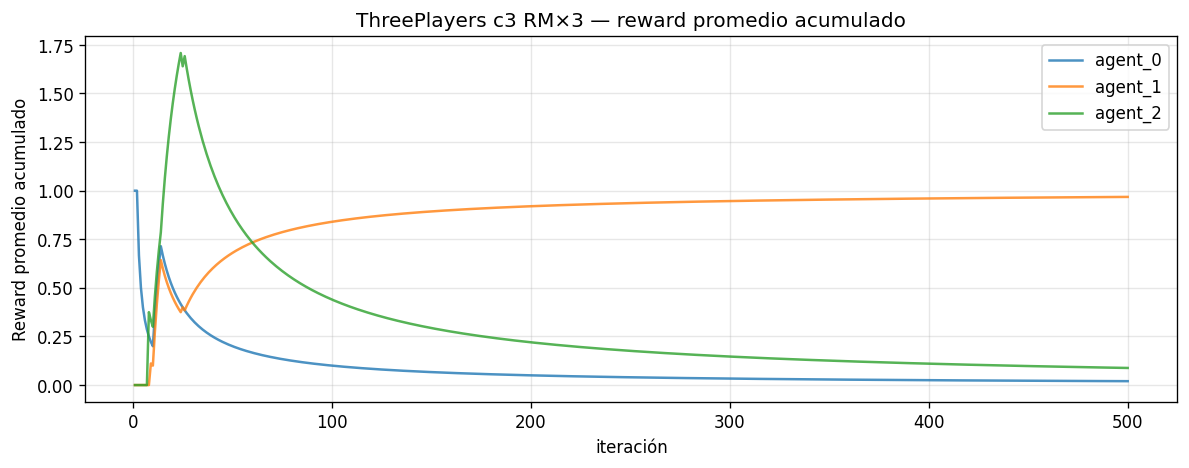

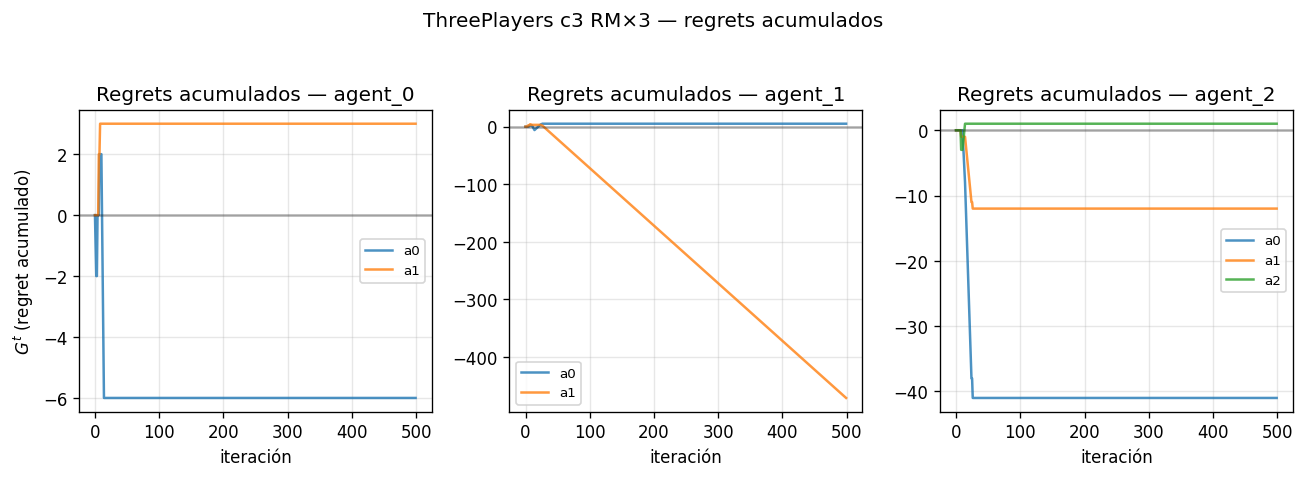

In [ ]:
# Gráficas adicionales — alineadas con MP/RPS
plot_pair(plot_distance_to_closest_nash, hist_c3_rm, nash_dicts3, save='c3_rm_x3_distance_to_nash', title='ThreePlayers c3 RM×3 — distancia al Nash puro más cercano')

plot_pair(plot_cumulative_average_reward, hist_c3_rm, save='c3_rm_x3_reward_cum_avg', title='ThreePlayers c3 RM×3 — reward promedio acumulado')

plot_pair(plot_cumulative_regret, hist_c3_rm, save='c3_rm_x3_cum_regrets', title='ThreePlayers c3 RM×3 — regrets acumulados')

### Mixto FP + RM + Random — config 3

Tres agentes de tipo distinto: uno greedy (FP), uno regret-matching (RM) y uno no estratégico (Random). Permite ver cómo se comporta cada algoritmo cuando enfrenta simultáneamente a un rival que aprende y a un rival no estratégico. En c3, agent_2 (Random) sortea uniforme entre 3 acciones (W/E/N), inyectando más varianza en las cantidades del rival no-estratégico.

In [ ]:
log.info('ThreePlayers c3 — FP + RM + Random — iniciando experimento')
pair_mix_c3 = [(FictitiousPlay, {'initial': init_c3}), (RegretMatching, {}), (RandomAgent, {})]
hist_c3_mix = exp.cached_run('threeplayers_c3_fp_rm_random', ThreePlayers(config=3), pair_mix_c3, iterations=ITERATIONS, seed=1)

for a in agents3:
    pol = hist_c3_mix['policy_history'][a][-1]
    am = int(np.argmax(pol)); lab = labels3[a][am]
    log.info(f'c3 FP+RM+Random — {a}: política final = {pol.round(3)} (argmax = {lab})')

2026-05-27 13:05:42 | INFO    | ThreePlayers c3 — FP + RM + Random — iniciando experimento


2026-05-27 13:05:42 | INFO    | c3 FP+RM+Random — agent_0: política final = [0. 1.] (argmax = B)


2026-05-27 13:05:42 | INFO    | c3 FP+RM+Random — agent_1: política final = [0. 1.] (argmax = R)


2026-05-27 13:05:42 | INFO    | c3 FP+RM+Random — agent_2: política final = [0.333 0.333 0.333] (argmax = W)


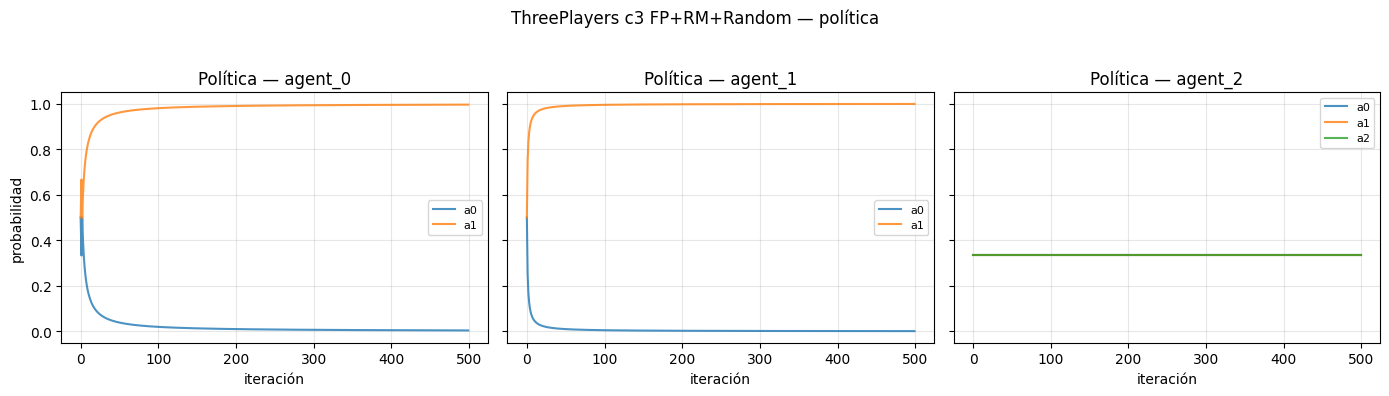

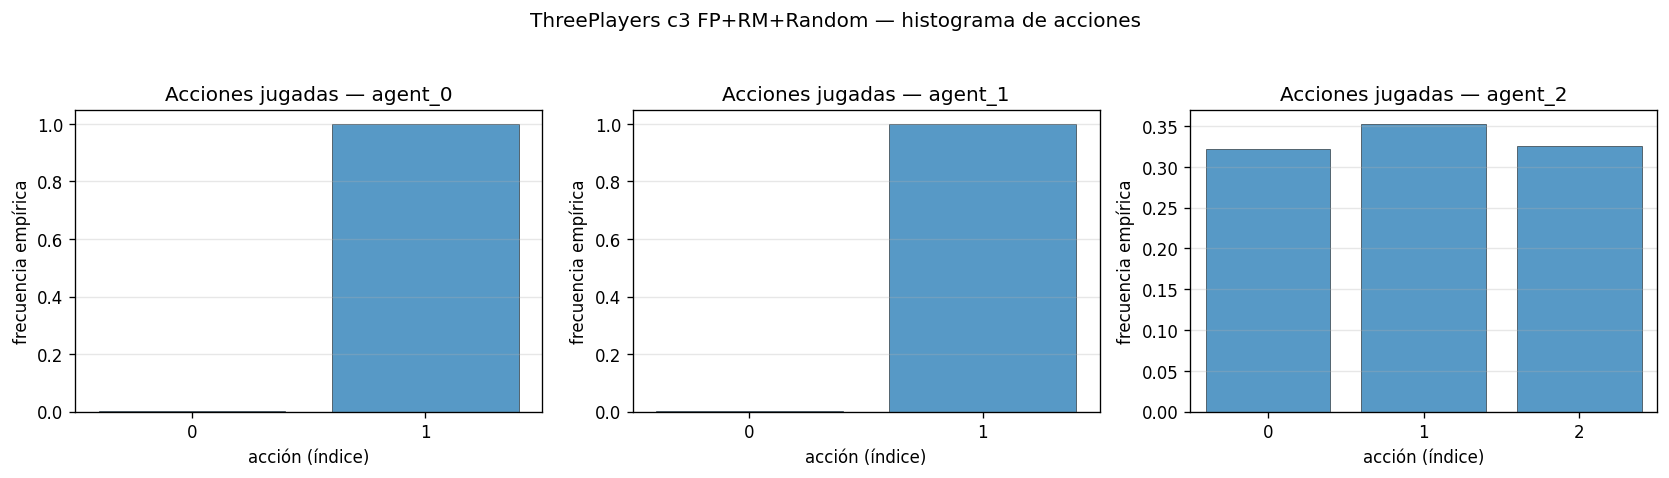

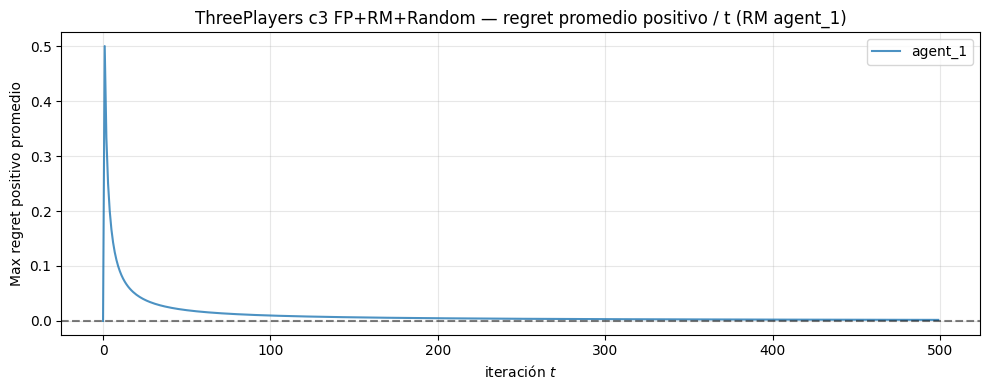

In [ ]:
plot_pair(plot_policy_evolution, hist_c3_mix, action_labels=None, figsize=(14, 4), save='c3_fp_rm_random_policy', title='ThreePlayers c3 FP+RM+Random — política')

plot_pair(plot_action_histogram, hist_c3_mix, figsize=(14, 4), save='c3_fp_rm_random_actions_hist', title='ThreePlayers c3 FP+RM+Random — histograma de acciones')

plot_pair(plot_average_positive_regret, hist_c3_mix, save='c3_fp_rm_random_avg_pos_regret', title='ThreePlayers c3 FP+RM+Random — regret promedio positivo / t (RM agent_1)')

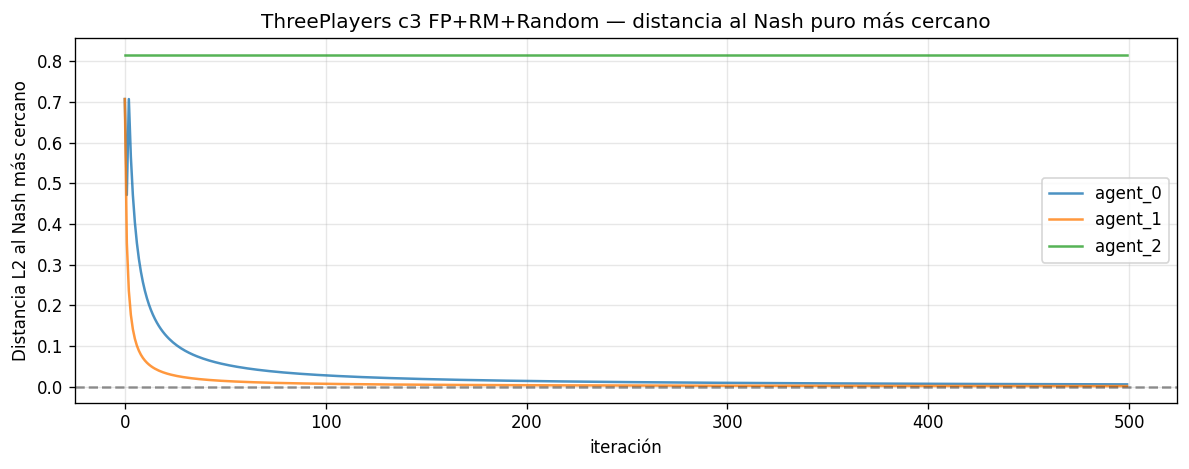

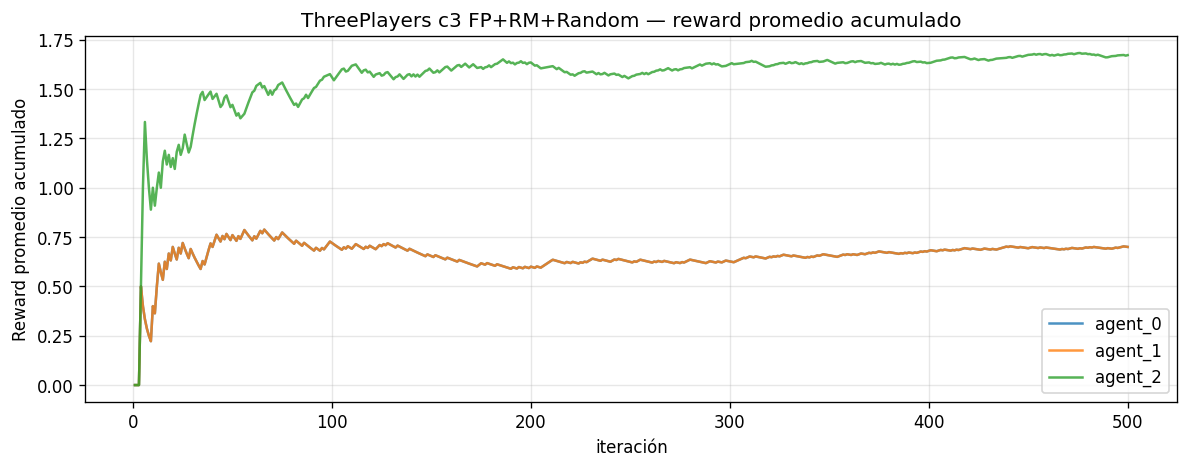

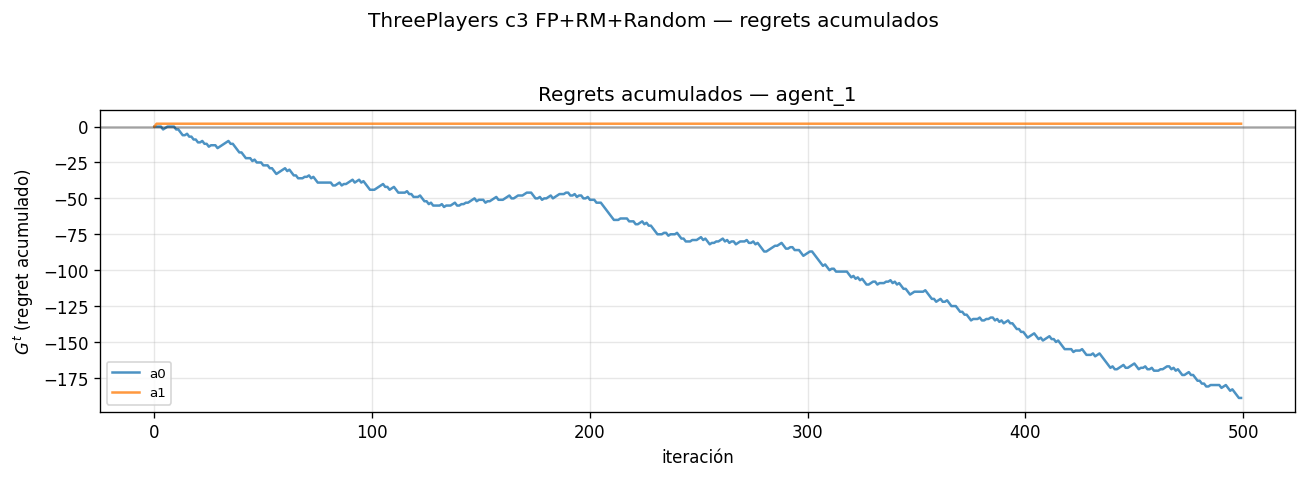

In [ ]:
# Gráficas adicionales — alineadas con MP/RPS
plot_pair(plot_distance_to_closest_nash, hist_c3_mix, nash_dicts3, save='c3_fp_rm_random_distance_to_nash', title='ThreePlayers c3 FP+RM+Random — distancia al Nash puro más cercano')

plot_pair(plot_cumulative_average_reward, hist_c3_mix, save='c3_fp_rm_random_reward_cum_avg', title='ThreePlayers c3 FP+RM+Random — reward promedio acumulado')

plot_pair(plot_cumulative_regret, hist_c3_mix, save='c3_fp_rm_random_cum_regrets', title='ThreePlayers c3 FP+RM+Random — regrets acumulados (RM agent_1)')

## Síntesis comparativa

Tabla resumen con todos los argmax finales por config y por pairing, junto a los Nash puros analíticos. Permite ver de un vistazo cuándo los algoritmos coordinan en un Nash puro, cuándo en uno de varios equivalentes, y cuándo no convergen a ninguno.

In [ ]:
configs_info = {
    1: ('Bonanno fig 2.22', [hist_c1_fp, hist_c1_rm, hist_c1_mix]),
    3: ('Aumann 2.5', [hist_c3_fp, hist_c3_rm, hist_c3_mix]),
}
pairing_names = ['FP×3', 'RM×3', 'FP+RM+Random']

print(f"{'Config':<10} {'Pairing':<14} {'agent_0':<10} {'agent_1':<10} {'agent_2':<10} {'¿Nash puro?':<14}")
print('=' * 76)
for cfg, (ref, hists) in configs_info.items():
    g_tmp = ThreePlayers(config=cfg); g_tmp.reset()
    info_tmp = g_tmp.get_config_info()
    n_acts = info_tmp['num_actions_per_agent']
    labs = info_tmp['action_labels']
    ne_list = find_pure_nash(g_tmp._R, n_acts)
    ne_set = {ne for ne, _ in ne_list}

    print(f'\nConfig {cfg} ({ref})')
    if ne_list:
        for ne, p in ne_list:
            pretty = tuple(labs[a][ne[i]] for i, a in enumerate(['agent_0','agent_1','agent_2']))
            print(f'  Nash puro: {pretty} payoff={list(p)}')
    else:
        print('  Nash puros: NINGUNO')
    for name, hist in zip(pairing_names, hists):
        chosen = []
        n_uniform = 0
        for i, a in enumerate(['agent_0','agent_1','agent_2']):
            policy = hist['policy_history'][a][-1]
            if np.allclose(policy, 1.0 / len(policy), atol=1e-3):
                chosen.append('uniforme')
                n_uniform += 1
            else:
                chosen.append(labs[a][int(np.argmax(policy))])
        # Si algún agente quedó en política ~uniforme, el argmax es arbitrario;
        # marcamos el check como '—' porque no tiene sentido comparar contra Nash puro
        if n_uniform > 0:
            is_ne = '—'
        else:
            argmaxes = tuple(int(np.argmax(hist['policy_history'][a][-1])) for a in ['agent_0','agent_1','agent_2'])
            is_ne = '✓' if argmaxes in ne_set else '✗'
        print(f"  {'':<8} {name:<14} {chosen[0]:<10} {chosen[1]:<10} {chosen[2]:<10} {is_ne:<14}")
    print('-' * 76)

Config     Pairing        agent_0    agent_1    agent_2    ¿Nash puro?   

Config 1 (Bonanno fig 2.22)
  Nash puro: ('B', 'R', 'W') payoff=[3.0, 4.0, 2.0]
           FP×3           B          R          W          ✓             
           RM×3           B          R          W          ✓             
           FP+RM+Random   B          L          uniforme   —             
----------------------------------------------------------------------------

Config 3 (Aumann 2.5)
  Nash puro: ('T', 'R', 'W') payoff=[0.0, 0.0, 0.0]
  Nash puro: ('T', 'R', 'N') payoff=[0.0, 0.0, 0.0]
  Nash puro: ('B', 'L', 'W') payoff=[1.0, 0.0, 0.0]
  Nash puro: ('B', 'L', 'N') payoff=[0.0, 1.0, 0.0]
           FP×3           uniforme   uniforme   E          —             
           RM×3           B          L          N          ✓             
           FP+RM+Random   B          R          uniforme   —             
----------------------------------------------------------------------------


---

**Notas**:

- Los `history` dicts quedan persistidos en `data/threeplayers/threeplayers_c{config}_*.pkl`.
- Las figuras se guardan en `images/threeplayers/c{config}_*.png`.
- El progreso queda en `logs/threeplayers/ThreePlayers.log`.